**Descargar e instalar el modelo de procesamiento de lenguaje natural pre-entrenado en español.**

**Importación de las librerias necesarias para la extración de la información.**





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import matplotlib
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.integrate import odeint
import matplotlib.image as mpimg
import plotly.io as pio
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm
import statsmodels.graphics.tsaplots as sgt
from wordcloud import WordCloud, ImageColorGenerator
from collections import Counter
import random
from PIL import Image
import re
from nltk.corpus import stopwords
import spacy
from spacy.lang.es.examples import sentences
import seaborn as sns
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer
from collections import defaultdict
import networkx as nx
from pyvis.network import Network
import plotly.express as px
from bertopic import plotting

**Importar los datos que se van a analizar.**

In [2]:
df = pd.read_csv(r"noticias_fentanilo completa - copia.csv")

In [3]:
palabras_a_buscar = ["fentanilo", "fentanil", "fentanyl", "fentaniloo"]

# --- Parte MODIFICADA para ELIMINAR varias columnas ---
# Define una LISTA con los nombres exactos de las columnas que quieres eliminar
columnas_a_eliminar = ["Unnamed: 7", "Unnamed: 8", "Unnamed: 9", "Unnamed: 10", "Unnamed: 11", "Unnamed: 12", "Unnamed: 13"] 

columnas_existentes = [col for col in columnas_a_eliminar if col in df.columns]

if columnas_existentes:
    df.drop(columns=columnas_existentes, inplace=True)
    print(f"Las siguientes columnas han sido eliminadas: {', '.join(columnas_existentes)}")
else:
    print("Advertencia: Ninguna de las columnas especificadas para eliminar fue encontrada.")
# --------------------------------------------------------

# 5. Buscar y Contar MÚLTIPLES palabras
# Iteramos sobre cada palabra en la lista
for palabra in palabras_a_buscar:
    # Creamos un nombre de columna único para el conteo de esta palabra
    nombre_columna_conteo = f'conteo_{palabra}'
    
    # Aplicamos la lógica de conteo a la columna 'cuerpo' para la palabra actual
    # Usamos .lower() para contar sin distinguir mayúsculas/minúsculas
    df[nombre_columna_conteo] = [
        str(texto).lower().count(palabra) 
        for texto in df['cuerpo']
    ]
    print(f"✅ Conteo de la palabra '{palabra}' completado en la columna '{nombre_columna_conteo}'.")


# 6. Mostrar el resultado (opcional)
print("\nPrimeras filas del DataFrame resultante con múltiples conteos:")
# Mostramos la columna 'cuerpo' y las nuevas columnas de conteo
columnas_a_mostrar = ['cuerpo'] + [f'conteo_{p}' for p in palabras_a_buscar]

df.to_csv('datos_con_multiples_conteos.csv', index=False)

Advertencia: Ninguna de las columnas especificadas para eliminar fue encontrada.
✅ Conteo de la palabra 'fentanilo' completado en la columna 'conteo_fentanilo'.
✅ Conteo de la palabra 'fentanil' completado en la columna 'conteo_fentanil'.
✅ Conteo de la palabra 'fentanyl' completado en la columna 'conteo_fentanyl'.
✅ Conteo de la palabra 'fentaniloo' completado en la columna 'conteo_fentaniloo'.

Primeras filas del DataFrame resultante con múltiples conteos:


**Formatear las columnas publish_date de las bases de datos a formato datetime.**

In [4]:
df['fecha'] = pd.to_datetime(df['fecha'])

**Agrupación 1: Conteo diario de noticias.**

In [15]:
# Agrupar columna publish_date por día y cuenta la cantidad de title por día
df_conteo_diario = df.groupby(df['fecha'].dt.date)['titular'].count().reset_index()

# Renombrar las columnas
df_conteo_diario.columns = ['fecha', 'count']

**Formatear las columnas de los dataframes con los conteos de noticias diarias a formato datetime.**

In [16]:
df_conteo_diario['fecha'] = pd.to_datetime(df_conteo_diario['fecha'])

**Gráfico: Conteo diario de noticias.**

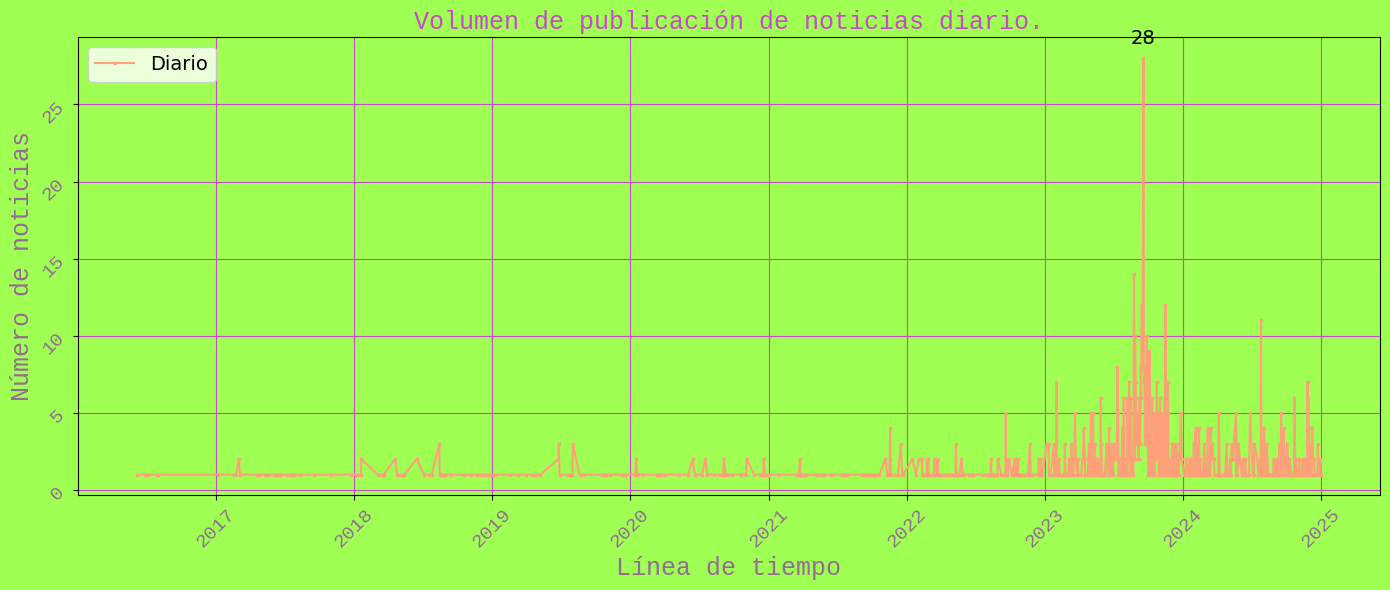

In [17]:
# Crear el gráfico de líneas
plt.figure(figsize=(14, 6), facecolor='#9FFF52')  # Ajusta el tamaño de la figura si es necesario
plt.plot(df_conteo_diario['fecha'], df_conteo_diario['count'], color='#FFA07A', marker='s', markersize=2, label='Diario')

# Personalizar el gráfico
plt.xlabel('Línea de tiempo', fontdict={'family': 'Liberation Mono', 'color': '#946c94', 'size': 18})
plt.ylabel('Número de noticias', fontdict={'family': 'Liberation Mono', 'color': '#946c94', 'size': 18})
plt.title('Volumen de publicación de noticias diario.', fontdict={'family': 'Liberation Mono', 'color': '#C74BC7', 'size': 18})
plt.grid(True, color='#C74BC7')
plt.xticks(rotation=45, color='#C74BC7')
plt.yticks(rotation=45, color='#C74BC7')
plt.setp(plt.gca().get_xticklabels(), fontfamily='Liberation Mono', fontsize=14, color='#946c94')
plt.setp(plt.gca().get_yticklabels(), fontfamily='Liberation Mono', fontsize=14, color='#946c94')
plt.tight_layout()

# Convenciones
plt.legend(loc='upper left', fontsize=14)

# Pico máximo alcanzado y el día en el que se alcanzó ese número.
max_es_idx = df_conteo_diario['count'].idxmax()

plt.annotate(f'{df_conteo_diario["count"].max()}', xy=(df_conteo_diario.loc[max_es_idx, 'fecha'], df_conteo_diario.loc[max_es_idx, 'count']), textcoords="offset points", xytext=(0,10), ha='center', fontsize=14, color='black')

# Agrega una convención para detallar que significa cada color
plt.annotate('', xy=(0.05, 0.9), xycoords='axes fraction', fontsize=14)

ax = plt.gca()
ax.set_facecolor('#9FFF52')

# Muestra el gráfico
plt.show()

**Series de tiempo: descomposición multiplicativa.**

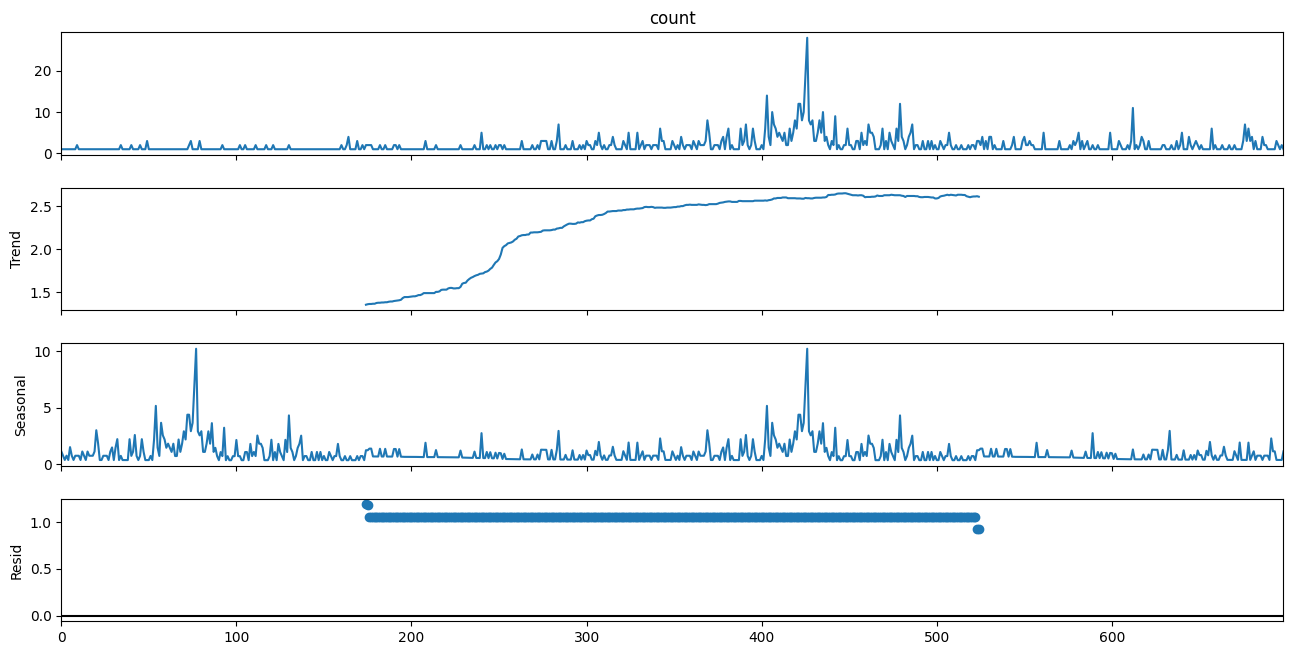

In [17]:
# Descomposición multiplicativa 
decomposition = seasonal_decompose(df_conteo_diario['count'], model='multiplicative', period=349)
fig = decomposition.plot()
fig.set_size_inches(14, 7)
plt.show()

**Gráfico: Tendencia.**

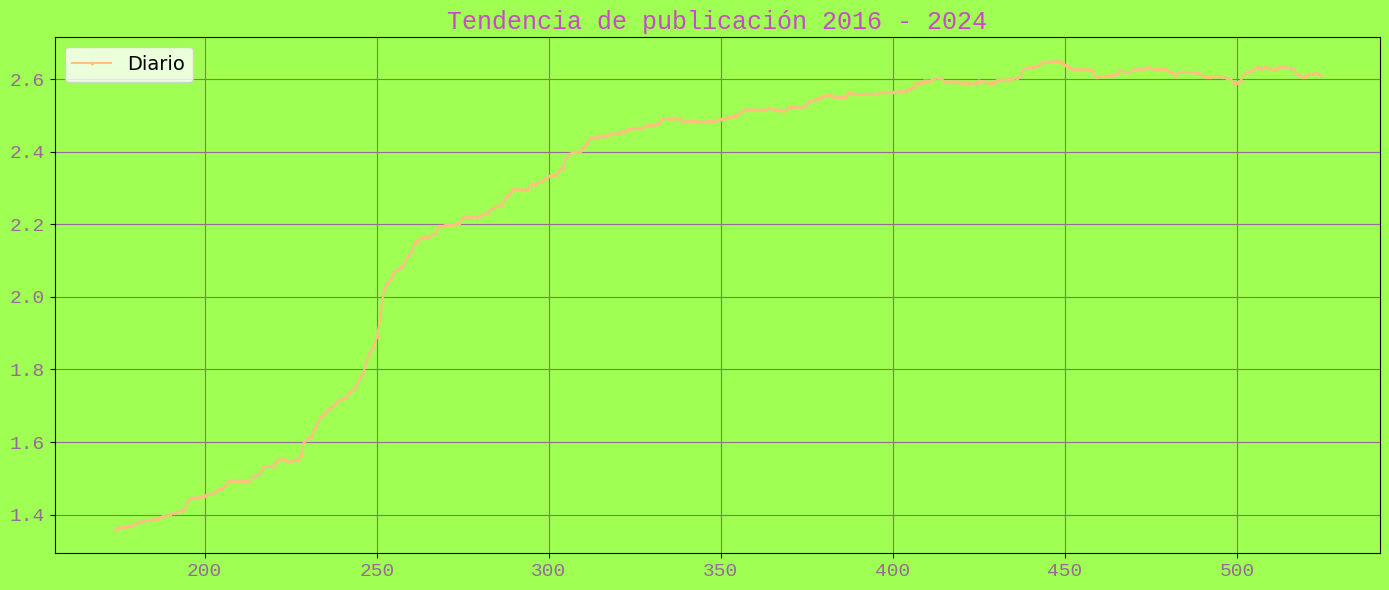

In [18]:
# Definir tendencias a graficar.
trend = decomposition.trend

# Crear gráfico de líneas.
fig, ax = plt.subplots(figsize=(14, 6), facecolor='#9FFF52')
ax.plot(trend, color='#FFC080', marker='s', markersize=2, label='Diario')

# Personalización del gráfico
plt.title('Tendencia de publicación 2016 - 2024', fontdict={'family': 'Liberation Mono', 'color': '#C74BC7', 'size': 18})
plt.xticks(color='#C74BC7')
plt.yticks(color='#C74BC7')
plt.setp(plt.gca().get_xticklabels(), fontfamily='Liberation Mono', fontsize=14, color='#946c94')
plt.setp(plt.gca().get_yticklabels(), fontfamily='Liberation Mono', fontsize=14, color='#946c94')
plt.tight_layout()
plt.grid(True, color='#946c94')
plt.legend(loc='upper left', fontsize=14)

ax = plt.gca()
ax.set_facecolor('#9FFF52')
plt.show()

**Gráfico: Estacionalidad.**

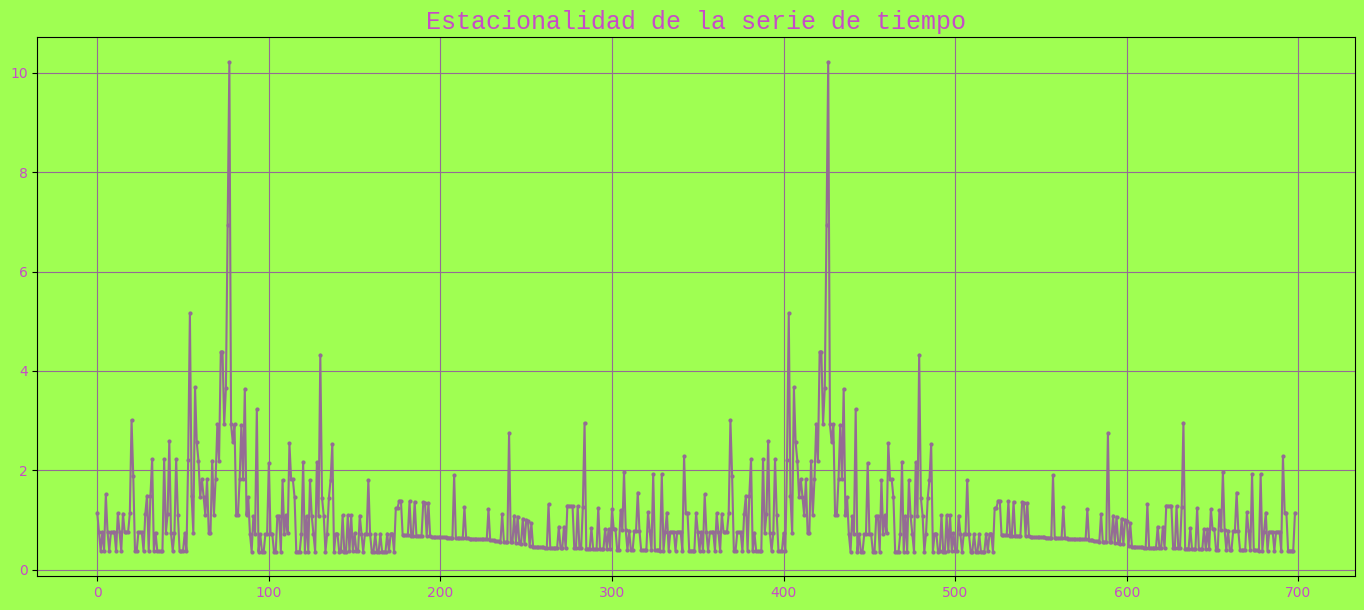

In [19]:
# Definir estacionalidad a graficar
seas = decomposition.seasonal

# Crear el gráfico de líneas,
fig, ax = plt.subplots(figsize=(17, 7), facecolor='#9FFF52')
ax.plot(seas, color='#946c94', marker='o', markersize=2)

# Personalización del gráfico
plt.title('Estacionalidad de la serie de tiempo', fontdict={'family': 'Liberation Mono', 'color': '#C74BC7', 'size': 18})
plt.xticks(color='#C74BC7')
plt.yticks(color='#C74BC7')
plt.grid(True, color='#946c94')

ax = plt.gca()
ax.set_facecolor('#9FFF52')

plt.show()

**Creación de nuevos dataframes con la columna fecha dividida en año, mes y día.**

In [18]:
df['fecha'] = pd.to_datetime(df['fecha'])

df_grouped = df.copy()
df_grouped['year'] = df_grouped['fecha'].dt.year
df_grouped['month'] = df_grouped['fecha'].dt.month
df_grouped['day'] = df_grouped['fecha'].dt.day

**Agrupación 2: Conteo de noticias por año.**

In [19]:
# Agrupa por año y cuenta la cantidad de títulos por año
yearly_title_counts_es = df_grouped.groupby('year')['titular'].count()

**Crear un dataframe con la Agrupación 2.**

In [20]:
yearly_title_counts_es_df = yearly_title_counts_es.reset_index()

**Gráfico : Volumen de noticias anual**

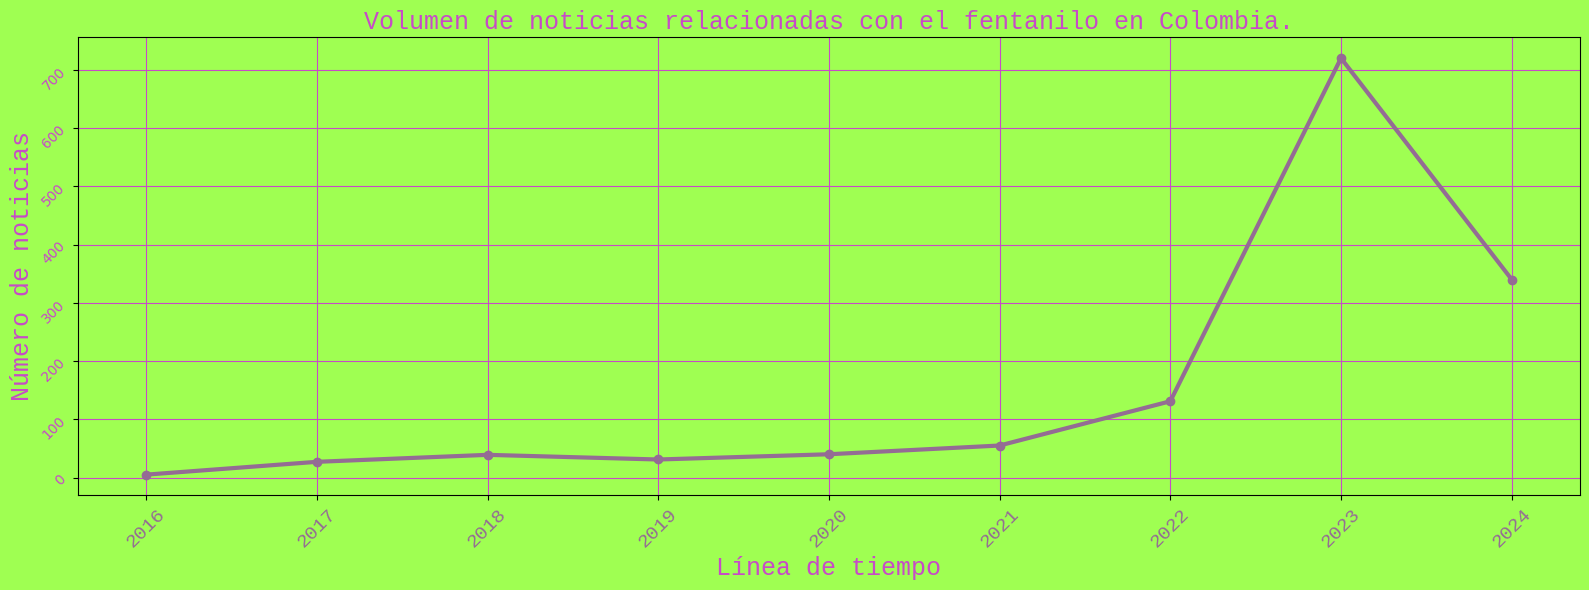

In [21]:
# Crea el gráfico de líneas
plt.figure(figsize=(16, 6), facecolor='#9FFF52')
plt.plot(yearly_title_counts_es_df['year'], yearly_title_counts_es_df['titular'], color='#946c94', marker='o', markersize=6, linewidth=3)

# Personalización el gráfico
plt.xlabel('Línea de tiempo', fontdict={'family': 'Liberation Mono', 'color': '#C74BC7', 'size': 18})
plt.ylabel('Número de noticias', fontdict={'family': 'Liberation Mono', 'color': '#C74BC7', 'size': 18})
plt.title('Volumen de noticias relacionadas con el fentanilo en Colombia.', fontdict={'family': 'Liberation Mono', 'color': '#C74BC7', 'size': 18})
plt.grid(True, color='#C74BC7')
plt.xticks(rotation=45, color='#C74BC7')
plt.yticks(rotation=45, color='#C74BC7')
plt.setp(plt.gca().get_xticklabels(), fontfamily='Liberation Mono', fontsize=14, color='#946c94')
plt.tight_layout()

ax = plt.gca()
ax.set_facecolor('#9FFF52')

# Muestra el gráfico
plt.show()

**Análisis de lenguaje natural, procesamiento de lenguaje natural.**

In [4]:
# Definir el modelo de procesamiento de lenguaje a utilizar
nlp = spacy.load('es_core_news_sm')

# Palabras a eliminar
palabras_a_eliminar = ['twitter', 'autor', 'suscripcion', 'image', 'com', 'pic', 'leer', 'acceder', 'querer', 'ver', 'facebook', 'instagram']

# Función para reemplazar tildes
def replace_tildes(text):
    replacements = {
        'á': 'a', 'é': 'e', 'í': 'i', 'ó': 'o', 'ú': 'u',
        'Á': 'A', 'É': 'E', 'Í': 'I', 'Ó': 'O', 'Ú': 'U',
        'ñ': 'n', 'Ñ': 'N'
    }
    for accented_char, unaccented_char in replacements.items():
        text = re.sub(accented_char, unaccented_char, text)
    return text

# Crear un set con las palabras a eliminar, todas en minúsculas y sin tildes para una búsqueda más rápida.
palabras_a_eliminar_set = set([replace_tildes(p.lower()) for p in palabras_a_eliminar])

def procesar_texto_corregido(texto):
    """
    Procesa el texto para lematizar, eliminar stopwords, puntuación, números
    y palabras específicas.
    """
    if not isinstance(texto, str):
        return ''

    # Procesar el texto original con SpaCy
    doc = nlp(texto)

    # Lematizar y procesar los tokens para que siempre estén en el mismo formato
    tokens_finales = []
    for token in doc:
        # Asegurarse de que el token no sea un stopword, puntuación o número
        if not token.is_stop and not token.is_punct and not token.like_num:
            # Obtener el lema del token, pasarlo a minúsculas y quitar las tildes
            lema_limpio = replace_tildes(token.lemma_.lower())
            
            # Si el lema limpio no está en la lista de palabras a eliminar, se añade
            if lema_limpio not in palabras_a_eliminar_set:
                tokens_finales.append(lema_limpio)
    
    # Unir los tokens en una cadena de texto
    preprocessed_text = ' '.join(tokens_finales)
    return preprocessed_text

# Aplica la función corregida a cada fila del DataFrame
df.loc[:, 'titular_preprocesado'] = df['titular'].apply(procesar_texto_corregido)
df.loc[:, 'cuerpo_preprocesado'] = df['cuerpo'].apply(procesar_texto_corregido)

**Nube de palabras con las palabras más frecuentes, dataframe procesado.**

-Titulares.

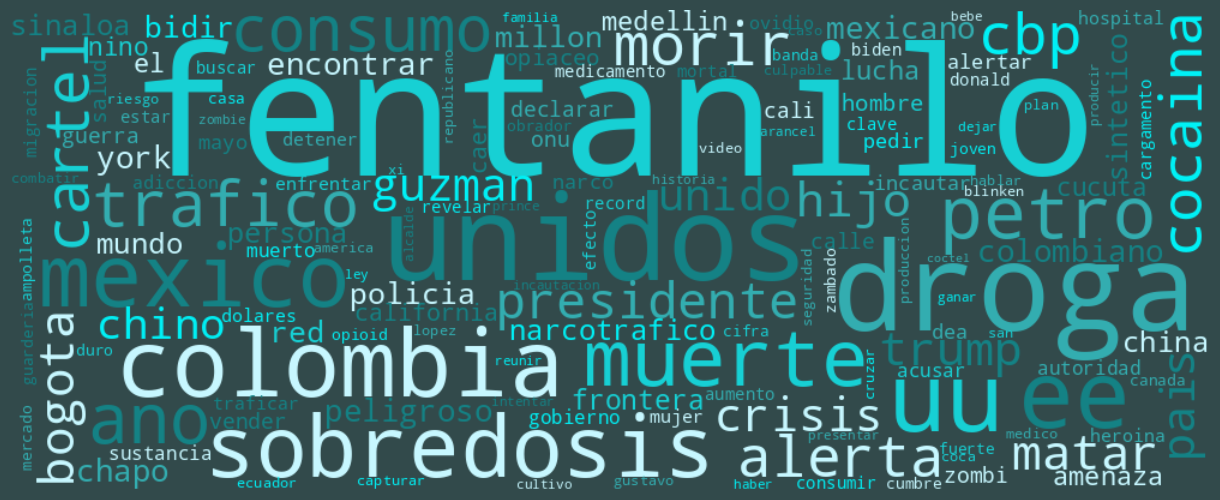

In [5]:
# Definir variable que contiene el texto preprocesado
texto = ' '.join(df['titular_preprocesado'])

# Crea un contador de palabras
contador = Counter(texto.split())

# Colores de las palabras de la nube
colores = {
    "azul1": "#00f0f5",
    "azul2": "#17D0D4",
    "azul3": "#C7F7FF",
    "azul4": "#33ADB0",
    "azul5": "#148285"
    
}

def color_func(word, font_size, position, orientation, random_state=None,
                    **kwargs):
    """
    Función para asignar colores aleatorios de verde o morado a las palabras.
    """
    verde_o_morado = random.choice(["verde", "morado"])
    if verde_o_morado == "verde":
        color = random.choice(list(colores.values())[3:])
    else:
        color = random.choice(list(colores.values())[:3])
    return color

# Creación y personalización de la nube de palabras
wordcloud = WordCloud(
    width=1000, height=400,
    font_path=None,
    background_color='#324a4b',
    max_words=150,
    contour_width=3,
    contour_color='black',
    margin=0,
    color_func=color_func,
).generate_from_frequencies(contador)


fig, ax = plt.subplots(figsize=(12, 6), facecolor='#324a4b')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

**Nube de palabras con las palabras más frecuentes, dataframe procesado.**

-Cuerpo de las noticias.

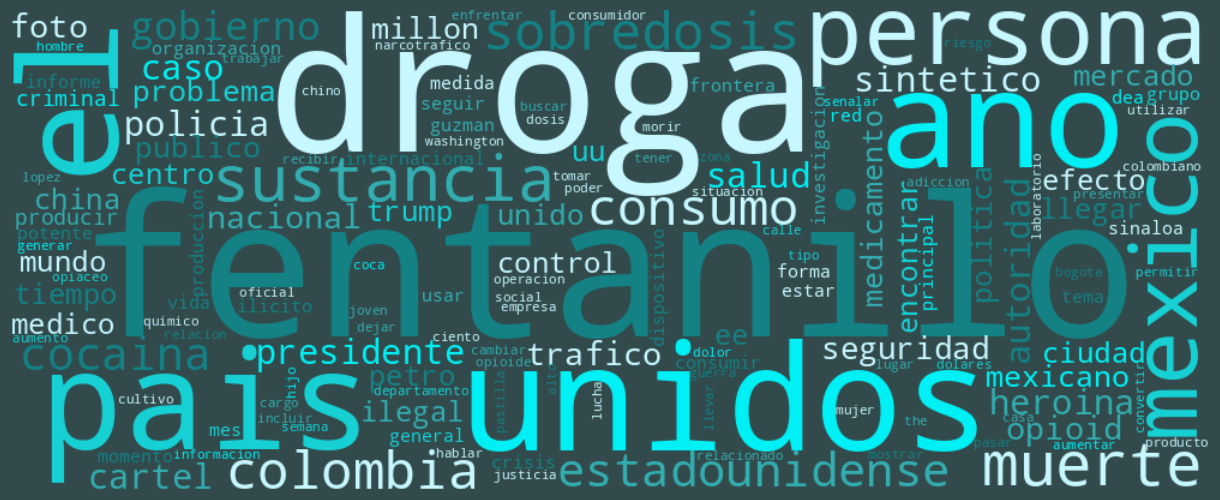

In [11]:
# Definir variable que contiene el texto preprocesado
texto = ' '.join(df['cuerpo_preprocesado'])

# Crea un contador de palabras
contador = Counter(texto.split())

# Colores de las palabras de la nube
colores = {
    "azul1": "#00f0f5",
    "azul2": "#17D0D4",
    "azul3": "#C7F7FF",
    "azul4": "#33ADB0",
    "azul5": "#148285"
    
}

def color_func(word, font_size, position, orientation, random_state=None,
                    **kwargs):
    """
    Función para asignar colores aleatorios de verde o morado a las palabras.
    """
    verde_o_morado = random.choice(["verde", "morado"])
    if verde_o_morado == "verde":
        color = random.choice(list(colores.values())[3:])
    else:
        color = random.choice(list(colores.values())[:3])
    return color

# Creación y personalización de la nube de palabras
wordcloud = WordCloud(
    width=1000, height=400,
    font_path=None,
    background_color='#324a4b',
    max_words=150,
    contour_width=3,
    contour_color='black',
    margin=0,
    color_func=color_func,
).generate_from_frequencies(contador)


fig, ax = plt.subplots(figsize=(12, 6), facecolor='#324a4b')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

**Análisis de temas: BERTopic.**

Usando la columna 'cuerpo_preprocesado' de 'df' para el análisis de temas.

Cargando modelo de embedding para español (SentenceTransformer)...


2026-04-22 11:00:49,911 - BERTopic - Embedding - Transforming documents to embeddings.


Modelo de embedding cargado exitosamente.
Inicializando y entrenando BERTopic (esto puede tomar un tiempo)...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

2026-04-22 11:02:19,774 - BERTopic - Embedding - Completed ✓
2026-04-22 11:02:19,786 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-22 11:03:19,249 - BERTopic - Dimensionality - Completed ✓
2026-04-22 11:03:19,265 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-22 11:03:19,977 - BERTopic - Cluster - Completed ✓
2026-04-22 11:03:19,978 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-22 11:03:20,804 - BERTopic - Representation - Completed ✓
2026-04-22 11:03:20,806 - BERTopic - Topic reduction - Reducing number of topics
2026-04-22 11:03:20,864 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-22 11:03:21,413 - BERTopic - Representation - Completed ✓
2026-04-22 11:03:21,416 - BERTopic - Topic reduction - Reduced number of topics from 9 to 9



¡Análisis de temas completado!

Número de tópicos encontrados: 8

Información de los Tópicos (Top 10):
   Topic  Count                                   Name  \
0     -1    344              -1_droga_fentanilo_el_ano   
1      0    199  0_mexico_unidos_cartel_estadounidense   
2      1    136    1_fentanilo_sobredosis_droga_opioid   
3      2    103   2_fentanilo_droga_heroina_sobredosis   
4      3     77     3_droga_policia_colombia_fentanilo   
5      4     56              4_el_autor_opinion_cucuta   
6      5     43          5_cbp_oficial_vehiculo_agente   
7      6     35          6_cocaina_coca_colombia_droga   
8      7     31    7_droga_fentanilo_sustancia_consumo   

                                      Representation  \
0  [droga, fentanilo, el, ano, pais, persona, sus...   
1  [mexico, unidos, cartel, estadounidense, trump...   
2  [fentanilo, sobredosis, droga, opioid, muerte,...   
3  [fentanilo, droga, heroina, sobredosis, person...   
4  [droga, policia, colombia, fenta

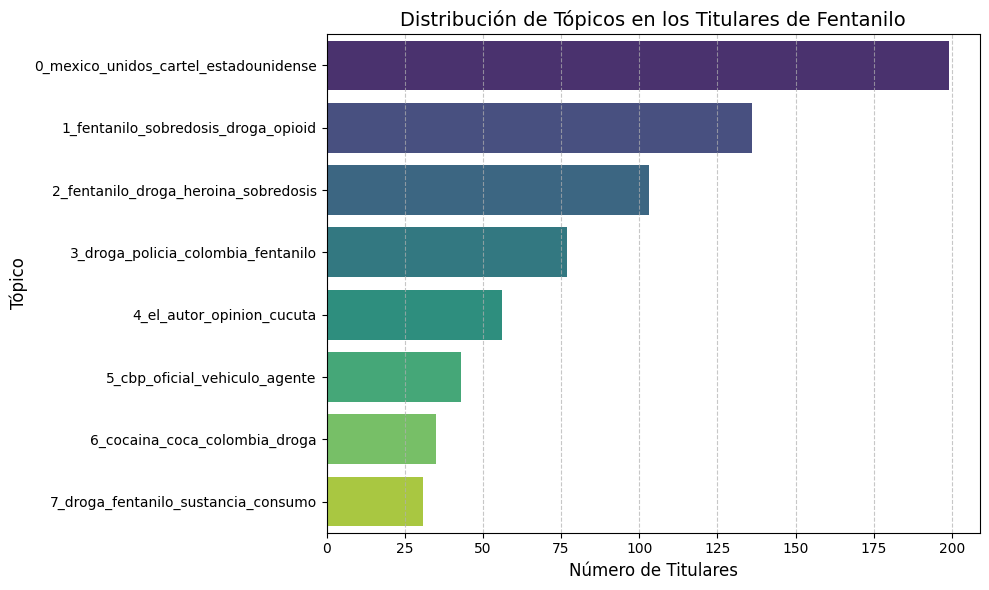

In [6]:
COLUMNA_TEXTO = 'cuerpo_preprocesado'

# Verificar si la columna de texto existe
if COLUMNA_TEXTO not in df.columns:
    print(f"\nError: La columna de texto especificada '{COLUMNA_TEXTO}' no fue encontrada en el DataFrame 'df'.")
    print(f"Las columnas disponibles son: {df.columns.tolist()}")
    print("Por favor, actualiza la variable 'COLUMNA_TEXTO' con el nombre de columna correcto.")
    exit()
else:
    print(f"Usando la columna '{COLUMNA_TEXTO}' de 'df' para el análisis de temas.")

# --- Preparar los documentos (lista de titulares) ---
# Asegurarse de que la columna sea de tipo string y manejar NaNs
documents = df[COLUMNA_TEXTO].astype(str).dropna().tolist()

if not documents:
    print("Error: No se encontraron titulares válidos para el análisis de temas. Verifica la columna.")
    exit()

# --- 2. Cargar el modelo de embedding para español ---
# 'paraphrase-MiniLM-L6-v2' es un modelo multilingüe que funciona bien para español.
# También puedes probar 'distilbert-base-multilingual-cased' para una base BERT multilingüe.
print("\nCargando modelo de embedding para español (SentenceTransformer)...")
try:
    embedding_model = SentenceTransformer("paraphrase-MiniLM-L6-v2")
    print("Modelo de embedding cargado exitosamente.")
except Exception as e:
    print(f"Error al cargar el modelo de embedding: {e}")
    print("Asegúrate de tener conexión a internet para descargar el modelo la primera vez.")
    print("Verifica que 'sentence-transformers' esté instalado.")
    exit()

# --- 3. Inicializar y entrenar BERTopic ---
print("Inicializando y entrenando BERTopic (esto puede tomar un tiempo)...")
# Puedes ajustar los parámetros de BERTopic para controlar el número y la calidad de los tópicos:
# nr_topics: 'auto' intenta encontrar el número óptimo. Puedes fijar un número (ej. 10).
# min_topic_size: Número mínimo de documentos por tópico.
# language: Asegura que el procesamiento de stopwords y c-TF-IDF sea adecuado.
topic_model = BERTopic(
    embedding_model=embedding_model,
    nr_topics="auto",         # Intenta encontrar el número óptimo de tópicos
    min_topic_size=20,         # Un tópico debe tener al menos 5 documentos
    language="spanish",       # Para usar stopwords en español y mejorar la coherencia
    calculate_probabilities=True, # Para obtener la probabilidad de cada documento por tópico
    verbose=True              # Muestra el progreso
)

# Entrenar el modelo con tus titulares
topics, probs = topic_model.fit_transform(documents)

print("\n¡Análisis de temas completado!")

# --- 4. Explorar los resultados ---

# Mostrar el número de tópicos encontrados
print(f"\nNúmero de tópicos encontrados: {len(topic_model.get_topic_info()) - 1}") # Restamos 1 por el tópico -1 (outliers)

# Obtener información de los tópicos
topic_info = topic_model.get_topic_info()
print("\nInformación de los Tópicos (Top 10):")
print(topic_info.head(10))

# Obtener las palabras clave de los tópicos (Top 5)
# El tópico -1 son los outliers/documentos que no encajan en ningún tópico claro.
print("\nPalabras clave de los Tópicos:")
for topic_id in topic_info["Topic"]:
    if topic_id != -1: # Ignorar el tópico de outliers
        words = topic_model.get_topic(topic_id)
        # Formatear la salida para mayor claridad
        topic_words = ", ".join([f"{word[0]} ({word[1]:.2f})" for word in words[:5]]) # Muestra palabra y su peso
        print(f"Tópico {topic_id} ({topic_info[topic_info['Topic'] == topic_id]['Count'].iloc[0]} documentos): {topic_words}")

# --- 5. Asignar los tópicos al DataFrame original ---
# Crear una nueva columna en tu DataFrame con el ID del tópico asignado a cada titular
df['Topic_ID'] = topics

# Asignar también el nombre representativo del tópico
# (topic_info['Name'] contiene la representación de palabras para el tópico)
topic_names = topic_info.set_index('Topic')['Name'].to_dict()
df['Topic_Name'] = df['Topic_ID'].map(topic_names)

print("\nPrimeras 10 filas del DataFrame con los IDs y Nombres de Tópicos:")
print(df[[COLUMNA_TEXTO, 'Topic_ID', 'Topic_Name']].head(10))

df_topics_filtered = df[df['Topic_ID'] != -1].copy()

# Calcula el número de tópicos visibles para ajustar la altura
num_topics_visible = df_topics_filtered['Topic_Name'].nunique()

# Define una altura dinámica para el gráfico.
# Multiplica el número de tópicos por un factor (0.7 es un buen punto de partida),
# y asegura una altura mínima (ej. 6 o 7 pulgadas).
# Puedes ajustar el factor '0.7' si las etiquetas siguen solapándose (prueba 0.8 o 1.0).
dynamic_height = max(6, num_topics_visible * 0.7)

plt.figure(figsize=(10, dynamic_height)) # Ancho fijo (10), altura dinámica

sns.countplot(
    y='Topic_Name',
    data=df_topics_filtered,
    # Ordena los tópicos por el número de titulares que contienen (los más grandes arriba)
    order=df_topics_filtered['Topic_Name'].value_counts().index,
    palette='viridis' # Puedes cambiar la paleta de colores si lo deseas
)

plt.title('Distribución de Tópicos en los Titulares de Fentanilo', fontsize=14)
plt.xlabel('Número de Titulares', fontsize=12)
plt.ylabel('Tópico', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10) # Ajusta el tamaño de la fuente de las etiquetas del eje Y (nombres de tópicos)
plt.grid(axis='x', linestyle='--', alpha=0.7) # Añade una cuadrícula para facilitar la lectura
plt.tight_layout() # Ajusta automáticamente los parámetros de la subtrama para un ajuste apretado
plt.show()

In [7]:
fig = topic_model.visualize_barchart(top_n_topics=10) # Puedes ajustar top_n_topics
fig.show()

In [8]:
fig = topic_model.visualize_hierarchy(top_n_topics=20)
fig.show()

AttributeError: Module 'scipy' has no attribute 'array'

**Análisis de entidades nombradas: SpaCy.**

In [8]:
COLUMNA_ORIGINAL = 'cuerpo_preprocesado'
NUEVA_COLUMNA_LIMPIA = 'cuerpo_cleaned_special_chars'

# Verificar que la columna original exista
if COLUMNA_ORIGINAL not in df.columns:
    print(f"\nError: La columna original '{COLUMNA_ORIGINAL}' no fue encontrada en el DataFrame 'df'.")
    print(f"Las columnas disponibles son: {df.columns.tolist()}")
    print("Por favor, actualiza la variable 'COLUMNA_ORIGINAL' con el nombre de columna correcto.")
    exit()

# --- Función para eliminar caracteres especiales ---
def remove_special_characters(text):
    if not isinstance(text, str):
        return "" # Retorna cadena vacía para valores no string

    # Expresión regular para mantener letras (a-z, A-Z, áéíóú, ñ, ÁÉÍÓÚ, Ñ), números (0-9) y espacios.
    # Cualquier otra cosa será eliminada.
    # r'[^a-zA-Z0-9áéíóúÁÉÍÓÚñÑ\s]' busca cualquier caracter que NO esté en el conjunto []
    # y lo reemplaza con un espacio vacío.
    cleaned_text = re.sub(r'[^a-zA-Z0-9áéíóúÁÉÍÓÚñÑ\s]', '', text)
    # También podemos normalizar espacios múltiples a un solo espacio y quitar espacios al inicio/final
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    return cleaned_text

# --- Aplicar la función a la columna original para crear la nueva columna ---
print(f"\nEliminando caracteres especiales de la columna '{COLUMNA_ORIGINAL}' y creando '{NUEVA_COLUMNA_LIMPIA}'...")
df[NUEVA_COLUMNA_LIMPIA] = df[COLUMNA_ORIGINAL].apply(remove_special_characters)
print("Eliminación de caracteres especiales completada.")

# --- Mostrar un ejemplo de los resultados ---
print(f"\nPrimeras 5 filas con la columna original y la nueva columna limpia:")
print(df[[COLUMNA_ORIGINAL, NUEVA_COLUMNA_LIMPIA]].head())

# Puedes verificar si hay NaNs después de la limpieza (aunque .fillna('') en la función ayuda)
print(f"\nConteo de valores nulos en '{NUEVA_COLUMNA_LIMPIA}': {df[NUEVA_COLUMNA_LIMPIA].isnull().sum()}")


Eliminando caracteres especiales de la columna 'cuerpo_preprocesado' y creando 'cuerpo_cleaned_special_chars'...
Eliminación de caracteres especiales completada.

Primeras 5 filas con la columna original y la nueva columna limpia:
                                 cuerpo_preprocesado  \
0  cantante icono musica pop fallecer ano abril c...   
1  filo caballo pequeno aldea mexicano guerrero p...   
2  farmaco utilizado sedar elefante animal potent...   
3  pais compruebir letal sustancia potente heroin...   
4  droga efecto similar heroina fuerte morfina mi...   

                        cuerpo_cleaned_special_chars  
0  cantante icono musica pop fallecer ano abril c...  
1  filo caballo pequeno aldea mexicano guerrero p...  
2  farmaco utilizado sedar elefante animal potent...  
3  pais compruebir letal sustancia potente heroin...  
4  droga efecto similar heroina fuerte morfina mi...  

Conteo de valores nulos en 'cuerpo_cleaned_special_chars': 0


Usando la columna 'cuerpo_cleaned_special_chars' de 'df' para el análisis de entidades nombradas.

Extrayendo entidades nombradas de los titulares...
Extracción de entidades completada.

Tipos de Entidades y sus Frecuencias:
- PER: 8273
- LOC: 6550
- ORG: 2354
- MISC: 1974

Entidades Más Frecuentes (Top 20):
- 'colombia' (LOC): 1287
- 'onu' (ORG): 278
- 'washington' (LOC): 204
- 'europa' (LOC): 193
- 'texas' (LOC): 160
- 'china' (LOC): 156
- 'york' (LOC): 149
- 'asia' (LOC): 145
- 'venezuela' (LOC): 141
- 'ucrania' (LOC): 141
- 'cdc' (ORG): 134
- 'california' (LOC): 111
- 'donald' (PER): 111
- 'manuel lopez obrador' (PER): 111
- 'sinaloa' (LOC): 97
- 'israel' (LOC): 95
- 'joaquin guzman' (PER): 89
- 'medellin' (PER): 88
- 'eeuu' (LOC): 86
- 'rusia' (LOC): 82


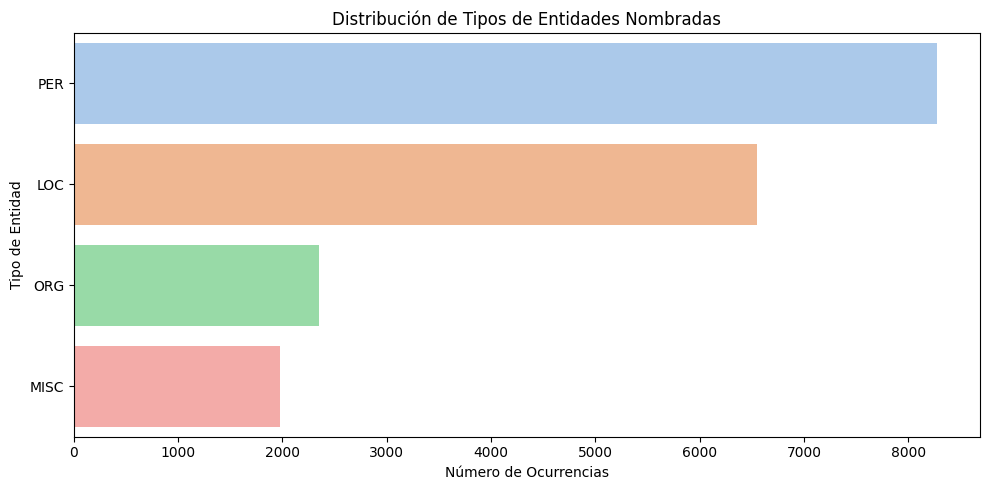

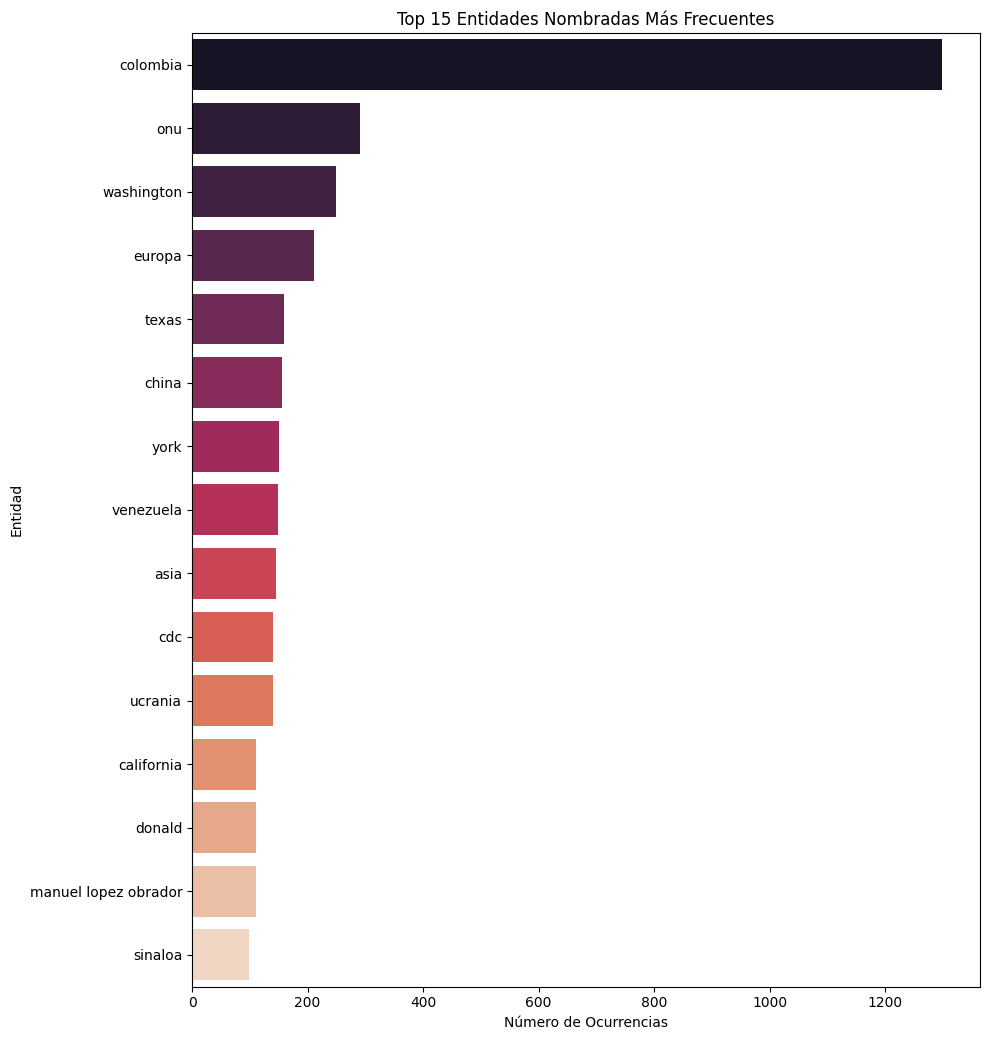

In [9]:
COLUMNA_TEXTO_NER = 'cuerpo_cleaned_special_chars'

# Verificar si la columna de texto existe en el DataFrame 'df_fentanilo'
if COLUMNA_TEXTO_NER not in df.columns:
    print(f"\nError: La columna de texto especificada para NER '{COLUMNA_TEXTO_NER}' no fue encontrada en el DataFrame 'df'.")
    print(f"Las columnas disponibles son: {df.columns.tolist()}")
    print("Por favor, actualiza la variable 'COLUMNA_TEXTO_NER' con el nombre de columna correcto.")
    # Considera usar 'raise ValueError' o 'sys.exit()' si quieres detener la ejecución programáticamente
    # import sys
    # sys.exit(1)
    exit() # Sale del script si la columna no se encuentra
else:
    print(f"Usando la columna '{COLUMNA_TEXTO_NER}' de 'df' para el análisis de entidades nombradas.")


# --- 2. Función para extraer entidades ---
def extraer_entidades(texto, nlp_model):
    if not isinstance(texto, str):
        return [] # Retorna lista vacía si no es string

    doc = nlp_model(texto)
    entities = []
    for ent in doc.ents:
        entities.append((ent.text, ent.label_))
    return entities

# --- 3. Aplicar la extracción de entidades al DataFrame ---
print("\nExtrayendo entidades nombradas de los titulares...")
# Usamos .fillna('') para asegurarnos de que no haya valores NaN que puedan causar errores en el procesamiento de texto.
df['entidades_detectadas'] = df[COLUMNA_TEXTO_NER].fillna('').apply(lambda x: extraer_entidades(x, nlp))
print("Extracción de entidades completada.")

# --- 4. Análisis de Frecuencia de Entidades ---
# Aplanar la lista de listas de entidades y contarlas
all_entities = [ent for sublist in df['entidades_detectadas'].tolist() for ent in sublist]

if all_entities:
    # Contar las entidades por tipo
    entity_counts_by_type = Counter([(ent_text, ent_type) for ent_text, ent_type in all_entities])

    # Contar solo los tipos de entidad
    entity_type_counts = Counter([ent_type for ent_text, ent_type in all_entities])

    print("\nTipos de Entidades y sus Frecuencias:")
    # Ordenar por frecuencia descendente
    for ent_type, count in entity_type_counts.most_common():
        print(f"- {ent_type}: {count}")

    print("\nEntidades Más Frecuentes (Top 20):")
    # Ordenar por frecuencia descendente
    for (entity, ent_type), count in entity_counts_by_type.most_common(20):
        print(f"- '{entity}' ({ent_type}): {count}")

    # --- 5. Visualización de los Tipos de Entidad más Comunes ---
    if entity_type_counts:
        df_entity_types = pd.DataFrame(entity_type_counts.most_common(), columns=['Tipo de Entidad', 'Frecuencia'])
        # Ajuste de altura dinámico para la visualización de tipos
        dynamic_height_types = max(5, len(df_entity_types) * 0.6)
        plt.figure(figsize=(10, dynamic_height_types))
        sns.barplot(x='Frecuencia', y='Tipo de Entidad', data=df_entity_types, palette='pastel')
        plt.title('Distribución de Tipos de Entidades Nombradas')
        plt.xlabel('Número de Ocurrencias')
        plt.ylabel('Tipo de Entidad')
        plt.tight_layout()
        plt.show()

    # --- 6. Visualización de las 15 Entidades Más Comunes ---
    top_entities_flat = [ent_text for ent_text, ent_type in all_entities]
    top_entities_counter = Counter(top_entities_flat)

    if top_entities_counter:
        df_top_entities = pd.DataFrame(top_entities_counter.most_common(15), columns=['Entidad', 'Frecuencia'])
        # Ajuste de altura dinámico para la visualización de entidades específicas
        dynamic_height_entities = max(6, len(df_top_entities) * 0.7)
        plt.figure(figsize=(10, dynamic_height_entities))
        sns.barplot(x='Frecuencia', y='Entidad', data=df_top_entities, palette='rocket')
        plt.title('Top 15 Entidades Nombradas Más Frecuentes')
        plt.xlabel('Número de Ocurrencias')
        plt.ylabel('Entidad')
        plt.tight_layout()
        plt.show()

else:
    print("\nNo se detectaron entidades nombradas en los documentos. Esto puede ocurrir si el DataFrame está vacío o los textos no contienen entidades reconocibles.")


**Análisis n-gramas: Sklearn (CountVectorizer).**

Usando la columna 'cuerpo_preprocesado' de 'df' para el análisis de n-gramas.

Realizando análisis de Unigramas (1 palabra)...
Top 20 Unigramas:
- 'fentanilo': 7909
- 'droga': 6993
- 'unidos': 4270
- 'el': 3942
- 'pais': 3675
- 'ano': 3611
- 'persona': 2505
- 'mexico': 2297
- 'sustancia': 2270
- 'muerte': 2092
- 'sobredosis': 2028
- 'colombia': 2003
- 'consumo': 1810
- 'estadounidense': 1665
- 'cocaina': 1601
- 'gobierno': 1576
- 'presidente': 1524
- 'cartel': 1483
- 'autoridad': 1461
- 'sintetico': 1448

Realizando análisis de Bigramas (2 palabras)...
Top 20 Bigramas:
- 'ee uu': 900
- 'muerte sobredosis': 594
- 'droga sintetico': 540
- 'cartel sinaloa': 496
- 'autor el': 417
- 'salud publico': 411
- 'lopez obrador': 375
- 'fentanilo droga': 370
- 'gustavo petro': 352
- 'trafico fentanilo': 322
- 'consumo droga': 317
- 'donald trump': 313
- 'millon dolares': 308
- 'trafico droga': 301
- 'opioide sintetico': 295
- 'twitter com': 294
- 'sigla ingles': 282
- 'consumo fentanilo': 282
- 'pi

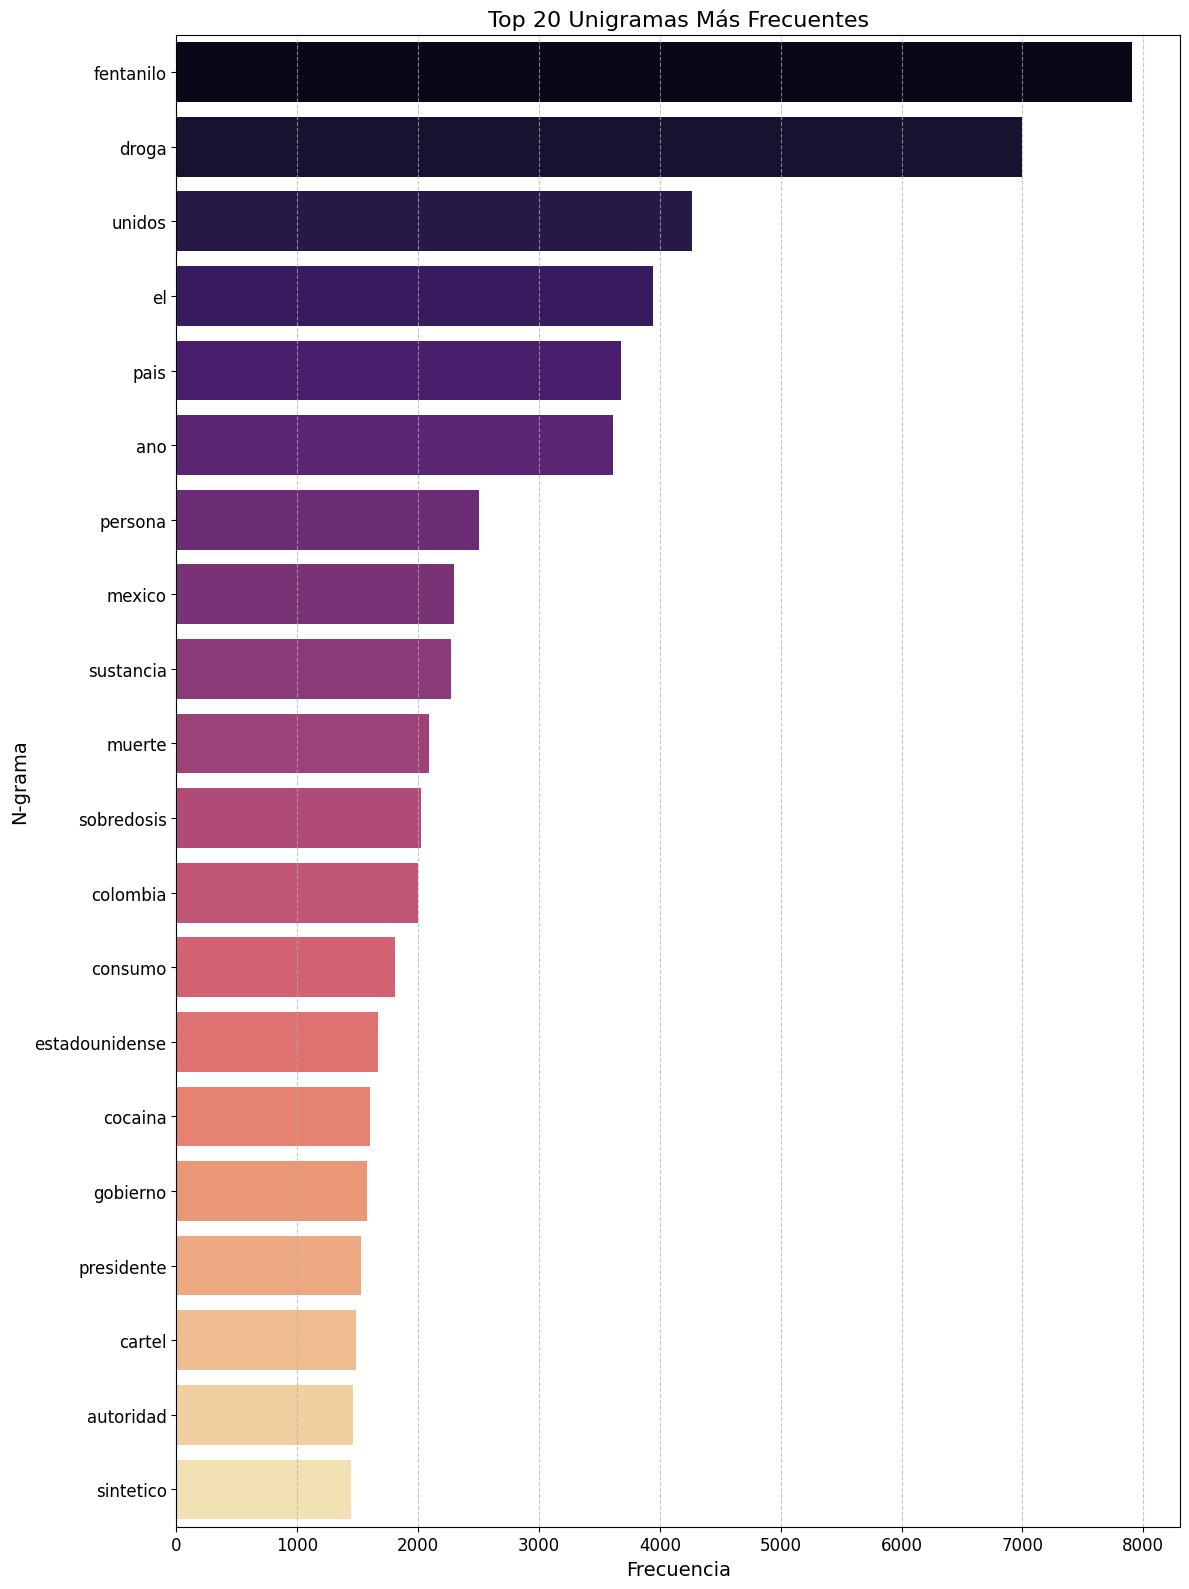

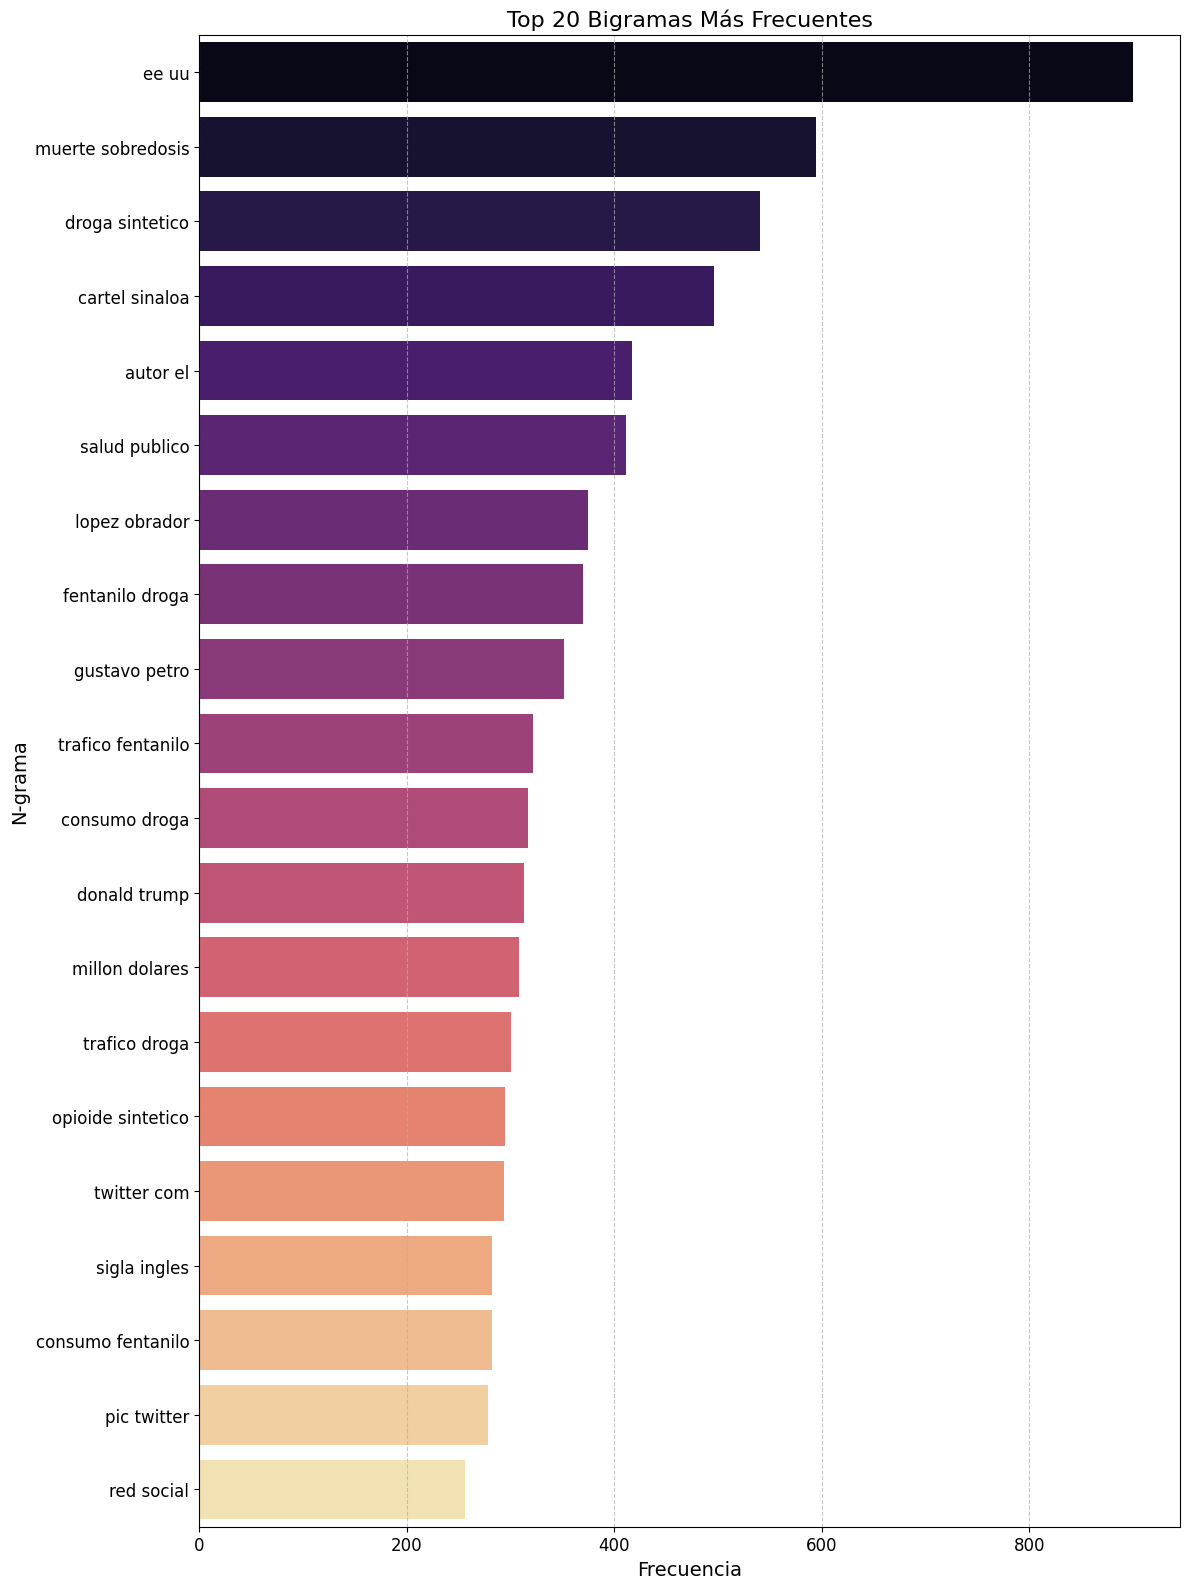

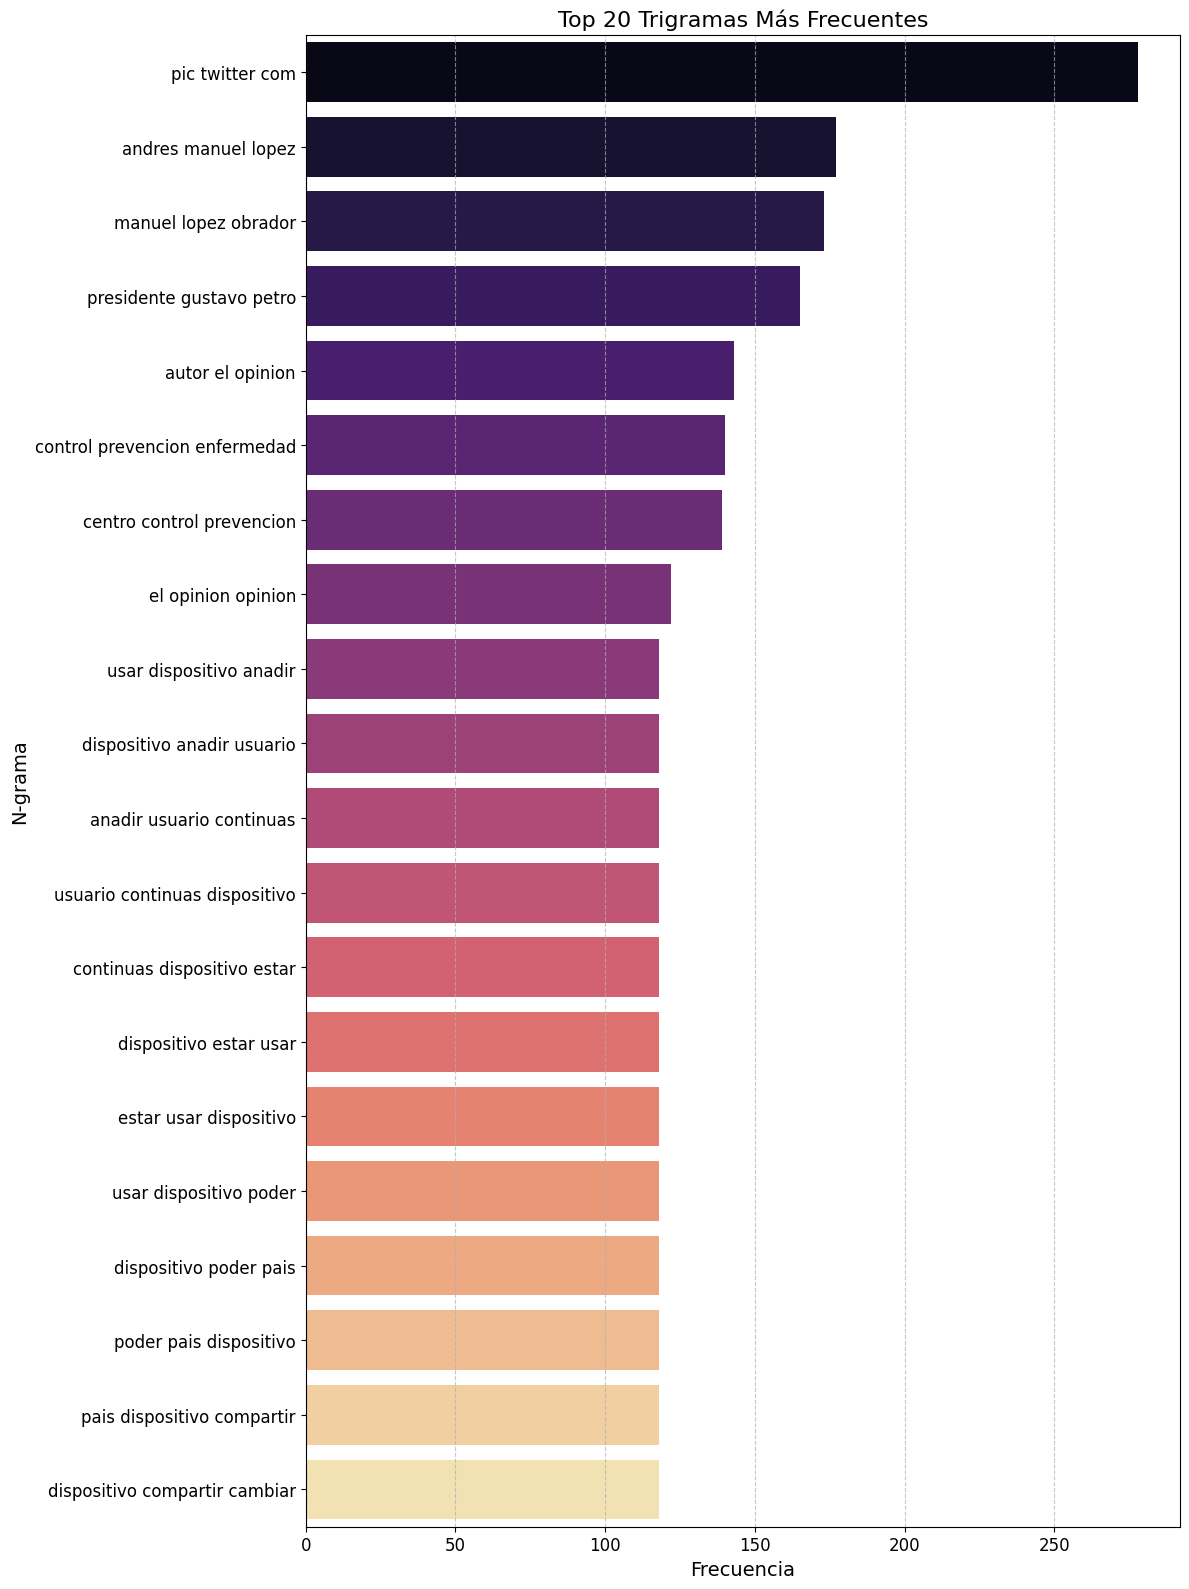


Análisis de n-gramas completado y gráficos generados.


In [11]:
COLUMNA_TEXTO_NGRAMAS = 'cuerpo_preprocesado' # Usaremos la columna preprocesada para n-gramas

# Verificar si la columna de texto existe en el DataFrame 'df_fentanilo'
if COLUMNA_TEXTO_NGRAMAS not in df.columns:
    print(f"\nError: La columna de texto especificada para n-gramas '{COLUMNA_TEXTO_NGRAMAS}' no fue encontrada en el DataFrame 'df'.")
    print(f"Las columnas disponibles son: {df.columns.tolist()}")
    print("Por favor, actualiza la variable 'COLUMNA_TEXTO_NGRAMAS' con el nombre de columna correcto.")
    exit()
else:
    print(f"Usando la columna '{COLUMNA_TEXTO_NGRAMAS}' de 'df' para el análisis de n-gramas.")

# Asegurarse de que los documentos son una lista de strings y manejar NaNs
documents_for_ngrams = df[COLUMNA_TEXTO_NGRAMAS].astype(str).dropna().tolist()

if not documents_for_ngrams:
    print("Error: No se encontraron documentos válidos para el análisis de n-gramas.")
    exit()

# --- 2. Función para obtener los N-gramas más frecuentes ---
def get_top_ngrams(corpus, n_min, n_max, top_k=20):
    # Usamos CountVectorizer para generar los n-gramas
    # analyzer='word' asegura que trabaje a nivel de palabras
    # ngram_range=(n_min, n_max) define el rango de tamaños de n-gramas a considerar
    vectorizer = CountVectorizer(ngram_range=(n_min, n_max), analyzer='word')
    X = vectorizer.fit_transform(corpus)

    # Suma las frecuencias de cada n-grama en todo el corpus
    sum_words = X.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    return words_freq[:top_k]

# --- 3. Ejecutar el análisis para diferentes tipos de N-gramas ---

print("\nRealizando análisis de Unigramas (1 palabra)...")
top_unigrams = get_top_ngrams(documents_for_ngrams, 1, 1, top_k=20)
print("Top 20 Unigramas:")
for word, freq in top_unigrams:
    print(f"- '{word}': {freq}")

print("\nRealizando análisis de Bigramas (2 palabras)...")
top_bigrams = get_top_ngrams(documents_for_ngrams, 2, 2, top_k=20)
print("Top 20 Bigramas:")
for phrase, freq in top_bigrams:
    print(f"- '{phrase}': {freq}")

print("\nRealizando análisis de Trigramas (3 palabras)...")
top_trigrams = get_top_ngrams(documents_for_ngrams, 3, 3, top_k=20)
print("Top 20 Trigramas:")
for phrase, freq in top_trigrams:
    print(f"- '{phrase}': {freq}")


# --- 4. Visualización de los N-gramas más frecuentes ---

def plot_ngrams(ngrams_data, title_suffix):
    if not ngrams_data:
        print(f"No hay datos para graficar {title_suffix}.")
        return

    df_ngrams = pd.DataFrame(ngrams_data, columns=['N-grama', 'Frecuencia'])

    # Ajuste de altura dinámico
    dynamic_height = max(6, len(df_ngrams) * 0.8) # Factor de 0.8 para dar más espacio

    plt.figure(figsize=(12, dynamic_height)) # Aumentamos el ancho para que las etiquetas largas quepan
    sns.barplot(x='Frecuencia', y='N-grama', data=df_ngrams, palette='magma')
    plt.title(f'Top {len(ngrams_data)} {title_suffix} Más Frecuentes', fontsize=16)
    plt.xlabel('Frecuencia', fontsize=14)
    plt.ylabel('N-grama', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

print("\nGenerando gráficos de N-gramas...")

# Graficar Unigramas
plot_ngrams(top_unigrams, "Unigramas")

# Graficar Bigramas
plot_ngrams(top_bigrams, "Bigramas")

# Graficar Trigramas
plot_ngrams(top_trigrams, "Trigramas")

print("\nAnálisis de n-gramas completado y gráficos generados.")

**Análisis de similud de co-ocurrencias de palabras: Sklearn.**

¡'df' ya está cargado! Continuando con el análisis de co-ocurrencias.

Vocabulario para co-ocurrencias (Top 50 palabras):
['alerta' 'amenaza' 'ano' 'bidir' 'bogota' 'cartel' 'cbp' 'chapo' 'china'
 'chino' 'cocaina' 'colombia' 'colombiano' 'consumo' 'crisis' 'cucuta'
 'droga' 'ee' 'el' 'encontrar']

Calculando la matriz de co-ocurrencias...
Matriz de co-ocurrencias calculada.

Fragmento de la Matriz de Co-ocurrencias (primeras 5x5):
         alerta  amenaza  ano  bidir  bogota  cartel  cbp  chapo  china  \
alerta        0        1    0      0       1       1    0      0      0   
amenaza       1        0    0      0       0       0    0      0      0   
ano           0        0    0      1       1       0    3      1      1   
bidir         0        0    1      0       0       1    0      0      1   
bogota        1        0    1      0       0       1    0      0      0   

         chino  ...  red  sinaloa  sintetico  sobredosis  trafico  trump  \
alerta       1  ...    1        0    

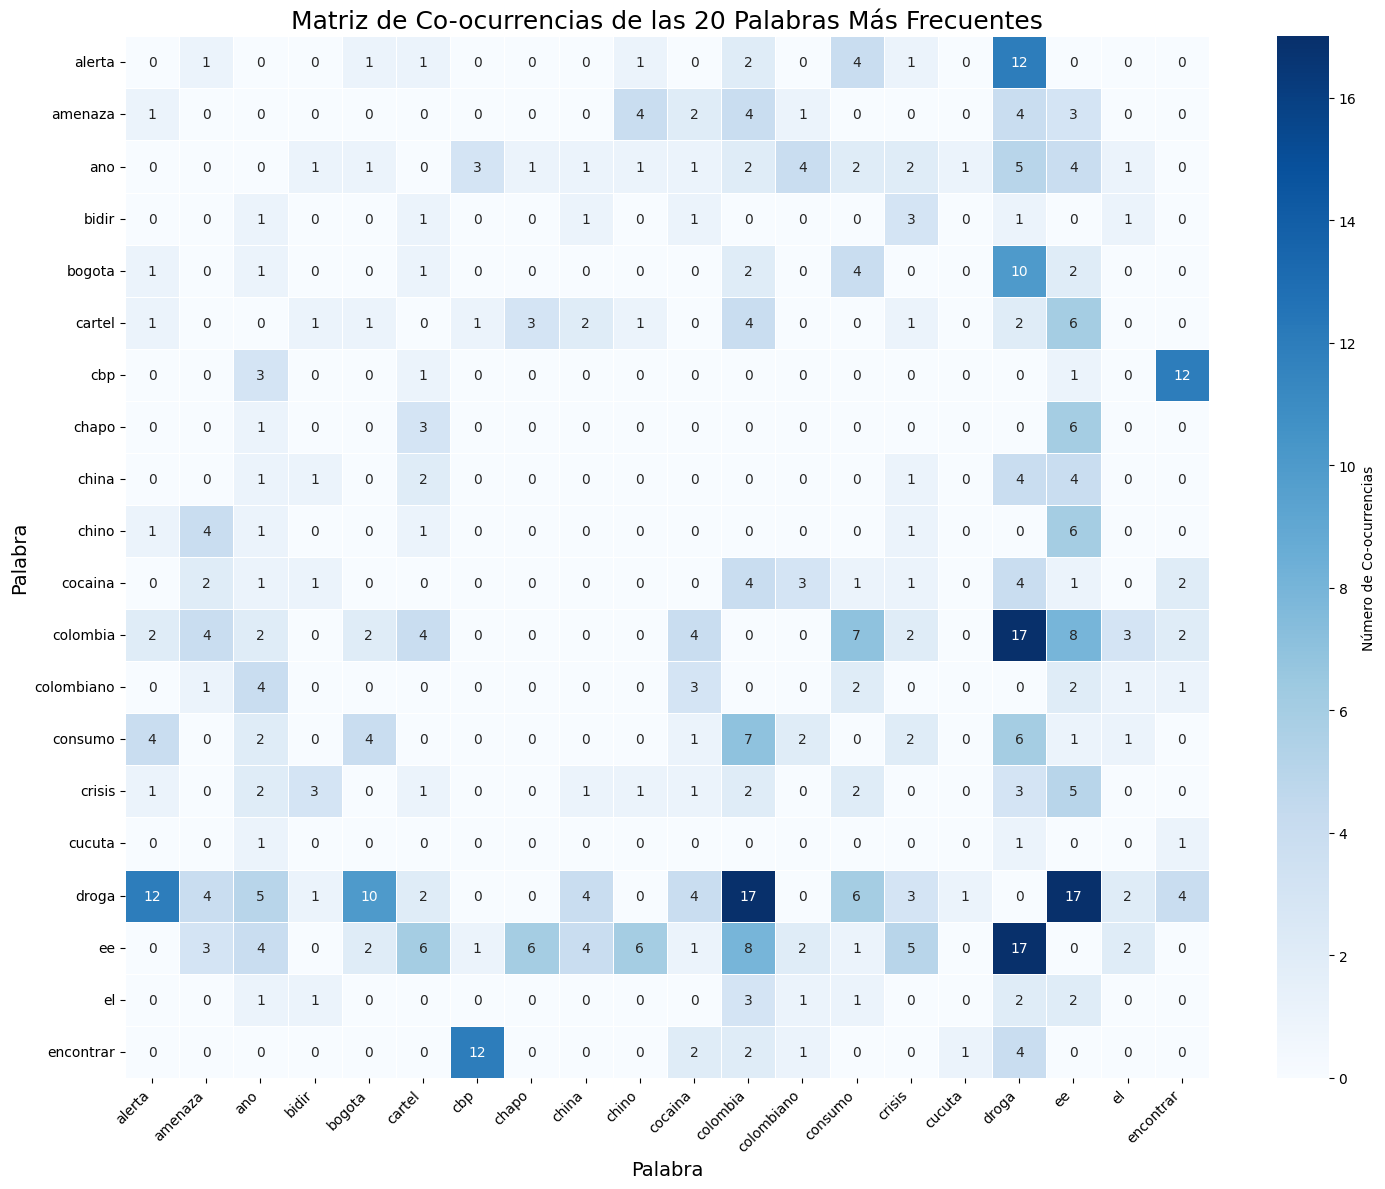


Top 15 Pares de Co-ocurrencias Más Fuertes (excluyendo auto-ocurrencias):
- ('colombia', 'droga'): 17 veces
- ('droga', 'ee'): 17 veces
- ('alerta', 'droga'): 12 veces
- ('cbp', 'encontrar'): 12 veces
- ('bogota', 'droga'): 10 veces
- ('colombia', 'ee'): 8 veces
- ('colombia', 'consumo'): 7 veces
- ('cartel', 'ee'): 6 veces
- ('chapo', 'ee'): 6 veces
- ('chino', 'ee'): 6 veces
- ('consumo', 'droga'): 6 veces
- ('ano', 'droga'): 5 veces
- ('crisis', 'ee'): 5 veces
- ('alerta', 'consumo'): 4 veces
- ('amenaza', 'chino'): 4 veces

Análisis de co-ocurrencias completado.


In [10]:
# --- 1. Configurar la columna de texto para el análisis de co-ocurrencias ---
# Se recomienda usar el texto preprocesado (sin stopwords, lematizado) para co-ocurrencias
# para enfocarse en palabras con significado y reducir el ruido.
COLUMNA_TEXTO_COOCURRENCIA = 'titular_preprocesado'

# Asumimos que df_fentanilo ya está cargado con tu columna 'preprocesado'
print("¡'df' ya está cargado! Continuando con el análisis de co-ocurrencias.")

# Verificar si la columna necesaria existe
if COLUMNA_TEXTO_COOCURRENCIA not in df.columns:
    print(f"\nError: La columna de texto preprocesado '{COLUMNA_TEXTO_COOCURRENCIA}' no fue encontrada en el DataFrame 'df'.")
    print(f"Las columnas disponibles son: {df.columns.tolist()}")
    print("Por favor, asegúrate de haber preprocesado el texto y que la columna exista.")
    exit()

# Asegurarse de que los documentos son una lista de strings y manejar NaNs
# También reiniciamos el índice si fue alterado por operaciones anteriores
df_coocurrencia_docs = df[[COLUMNA_TEXTO_COOCURRENCIA]].copy()
df_coocurrencia_docs.dropna(subset=[COLUMNA_TEXTO_COOCURRENCIA], inplace=True)
df_coocurrencia_docs.reset_index(drop=True, inplace=True)

documents_for_cooc = df_coocurrencia_docs[COLUMNA_TEXTO_COOCURRENCIA].tolist()

if not documents_for_cooc:
    print("Error: No se encontraron documentos válidos para el análisis de co-ocurrencias.")
    exit()

# --- 2. Preparar el CountVectorizer ---
# Usaremos CountVectorizer para obtener la matriz de términos por documento.
# max_features puede limitar el vocabulario a las palabras más frecuentes.
# Puedes ajustar stop_words si no estás usando un preprocesamiento que ya las elimine.
vectorizer = CountVectorizer(max_features=50) # Limitar a las 100 palabras más frecuentes para la matriz

# Aprender el vocabulario y transformar los documentos en una matriz de recuentos
X = vectorizer.fit_transform(documents_for_cooc)
vocab = vectorizer.get_feature_names_out() # Obtener las palabras correspondientes a las columnas

print(f"\nVocabulario para co-ocurrencias (Top {len(vocab)} palabras):")
print(vocab[:20]) # Mostrar las primeras 20 palabras del vocabulario

# --- 3. Calcular la Matriz de Co-ocurrencias ---
# Esto se hace multiplicando la matriz X por su transpuesta X.T
# La idea es que si dos palabras aparecen en el mismo documento, su producto en la matriz
# de co-ocurrencias será distinto de cero.
# X es (num_documentos, num_palabras)
# X.T es (num_palabras, num_documentos)
# La multiplicación X.T * X resulta en (num_palabras, num_palabras)
# que es nuestra matriz de co-ocurrencias
print("\nCalculando la matriz de co-ocurrencias...")
co_occurrence_matrix = (X.T * X) # Multiplicación de matrices dispersas

# Convertir la matriz a un array denso para facilitar la manipulación si no es muy grande
co_occurrence_matrix = co_occurrence_matrix.toarray()

# Para la diagonal (palabra co-ocurre consigo misma), podemos poner 0
# o mantener el conteo total de la palabra, dependiendo de lo que quieras visualizar.
# Si quieres solo co-ocurrencias entre PALABRAS DISTINTAS, pon la diagonal en 0.
np.fill_diagonal(co_occurrence_matrix, 0)
print("Matriz de co-ocurrencias calculada.")

# --- 4. Crear un DataFrame de la matriz de co-ocurrencias para mejor visualización ---
df_cooccurrence = pd.DataFrame(co_occurrence_matrix, columns=vocab, index=vocab)

print("\nFragmento de la Matriz de Co-ocurrencias (primeras 5x5):")
print(df_cooccurrence.head())

# --- 5. Visualización de la Matriz de Co-ocurrencias (Mapa de Calor) ---
# Selecciona un subconjunto de las palabras más frecuentes para la visualización,
# ya que 100 palabras podrían ser demasiado para un mapa de calor legible.
num_top_words_to_plot = 20 # Puedes ajustar este número (e.g., 10, 15, 25)

if len(vocab) < num_top_words_to_plot:
    num_top_words_to_plot = len(vocab)

# Obtener las palabras más frecuentes para el gráfico
# Podemos basarnos en las sumas de filas/columnas en la matriz de co-ocurrencia
# o simplemente las palabras top de CountVectorizer.
# Aquí usaremos las top X de nuestro vocabulario de CountVectorizer.
words_for_plot = vocab[:num_top_words_to_plot]
df_cooccurrence_plot = df_cooccurrence.loc[words_for_plot, words_for_plot]


plt.figure(figsize=(15, 12)) # Ajusta el tamaño de la figura para una mejor visibilidad
sns.heatmap(
    df_cooccurrence_plot,
    annot=True,          # Mostrar los valores de co-ocurrencia en las celdas
    cmap='Blues',        # Mapa de colores (puedes probar 'viridis', 'magma', 'coolwarm')
    fmt='g',             # Formato para los números (general, sin notación científica)
    linewidths=.5,       # Líneas entre las celdas
    cbar_kws={'label': 'Número de Co-ocurrencias'} # Etiqueta para la barra de color
)
plt.title(f'Matriz de Co-ocurrencias de las {num_top_words_to_plot} Palabras Más Frecuentes', fontsize=18)
plt.xlabel('Palabra', fontsize=14)
plt.ylabel('Palabra', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotar etiquetas para que no se solapen
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# --- 6. Análisis adicional: Encontrar las co-ocurrencias más fuertes (si el mapa de calor es muy denso) ---
print("\nTop 15 Pares de Co-ocurrencias Más Fuertes (excluyendo auto-ocurrencias):")
cooc_pairs = []
for i in range(num_top_words_to_plot):
    for j in range(i + 1, num_top_words_to_plot): # Solo la mitad superior para pares únicos
        word1 = words_for_plot[i]
        word2 = words_for_plot[j]
        count = df_cooccurrence_plot.loc[word1, word2]
        if count > 0: # Solo si co-ocurren al menos una vez
            cooc_pairs.append(((word1, word2), count))

cooc_pairs_sorted = sorted(cooc_pairs, key=lambda item: item[1], reverse=True)

for (word1, word2), count in cooc_pairs_sorted[:15]:
    print(f"- ('{word1}', '{word2}'): {count} veces")

print("\nAnálisis de co-ocurrencias completado.")

**Gráfico: Visualización de red**

In [12]:
# Convertimos el DataFrame de co-ocurrencias en un grafo de NetworkX
G = nx.from_pandas_adjacency(df_cooccurrence)

# INSINAR EL GRAFO ANTES DE LIMPIARLO
print(f"\nGrafo inicial: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas.")

# Define un umbral para el peso de las aristas.
# Esto es crucial para limpiar la visualización y mostrar solo las conexiones más fuertes.
# Puedes ajustar este valor (por ejemplo, 1, 2, 5, etc.)
umbral_peso = 2

# Eliminar las aristas con un peso menor al umbral.
# Esto remueve las co-ocurrencias débiles.
edges_to_remove = [(u, v) for u, v, data in G.edges(data=True) if data['weight'] < umbral_peso]
G.remove_edges_from(edges_to_remove)

# Eliminar los nodos que se quedaron sin conexiones después de la limpieza.
isolated_nodes = list(nx.isolates(G))
G.remove_nodes_from(isolated_nodes)

print(f"\nGrafo de co-ocurrencia creado y limpiado.")
print(f"El grafo final tiene {G.number_of_nodes()} nodos y {G.number_of_edges()} aristas.")


Grafo inicial: 50 nodos, 580 aristas.

Grafo de co-ocurrencia creado y limpiado.
El grafo final tiene 50 nodos y 366 aristas.


In [13]:
# Crear una instancia de la clase Network de Pyvis
net = Network(height="750px", width="100%", bgcolor="#222222", font_color="white", notebook=True)

# Añadir los nodos y las aristas al grafo de Pyvis manualmente
for node_id in G.nodes():
    node_degree = G.degree(node_id)
    node_size = G.degree(node_id) * 2 + 4
    node_color = '#548996' if node_degree > 10 else '#4CAF50'
    net.add_node(
        node_id,
        label=node_id,
        size=node_size,
        color=node_color,
        title=f"Conexiones: {node_degree}",
        font={'size': 24, 'color': 'white', 'face': 'Verdana', 'weight': 'bold'}
    )

for u, v, weight in G.edges(data='weight'):
    if weight is not None:
        net.add_edge(u, v, width=weight / 2, title=f"Co-ocurrencia: {weight}")

# Configurar y deshabilitar la física
net.toggle_physics(True)  # Activar la física para la organización inicial

# Añadir un botón para desactivar la física.
# Esto genera un menú en la visualización donde puedes controlar la física.
net.show_buttons(filter_=['physics'])

# Generar y guardar el archivo HTML
net.show("network_coocurrencia.html")

print("\nVisualización de red generada. Abre el archivo 'network_coocurrencia.html' en tu navegador.")

network_coocurrencia.html

Visualización de red generada. Abre el archivo 'network_coocurrencia.html' en tu navegador.


**Gráfico: Palabras más usadas y los medios que más las usaron.**

In [14]:
# 1. Obtener los 10 unigramas más frecuentes
def get_top_ngrams(corpus, n_min, n_max, top_k):
    vectorizer = CountVectorizer(ngram_range=(n_min, n_max), analyzer='word')
    X = vectorizer.fit_transform(corpus)
    sum_words = X.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

documents_for_ngrams = df['cuerpo_preprocesado'].astype(str).dropna().tolist()
top_unigrams = get_top_ngrams(documents_for_ngrams, 1, 1, top_k=10)
top_words = [word for word, freq in top_unigrams]

# 2. Obtener los 5 medios más importantes y agrupar el resto
top_10_medios = df['medio'].value_counts().nlargest(10).index.tolist()
df['medio_agrupado'] = df['medio'].apply(lambda x: x if x in top_10_medios else 'Otros')
medios_a_analizar = top_10_medios + ['Otros']

# 3. Contar la frecuencia de cada palabra por medio
df_plot_data = []
for medio in medios_a_analizar:
    df_medio = df[df['medio_agrupado'] == medio]
    text_medio = ' '.join(df_medio['cuerpo_preprocesado'].astype(str).tolist())
    word_counts = Counter(text_medio.split())
    
    for word in top_words:
        df_plot_data.append({
            'Palabra': word,
            'Medio': medio,
            'Frecuencia': word_counts[word]
        })

df_plot = pd.DataFrame(df_plot_data)

# Ordenar las palabras por frecuencia total
word_order = df_plot.groupby('Palabra')['Frecuencia'].sum().sort_values(ascending=False).index
df_plot['Palabra'] = pd.Categorical(df_plot['Palabra'], categories=word_order, ordered=True)
df_plot.sort_values('Palabra', inplace=True)

In [15]:
# Crear el gráfico de barras apiladas interactivo con Plotly
fig = px.bar(
    df_plot,
    x='Frecuencia',
    y='Palabra',
    color='Medio',
    orientation='h',  # Orientación horizontal como en el gráfico que quieres
    title='Palabras Clave más Frecuentes por Medio de Comunicación',
    labels={'Frecuencia': 'Conteo de Palabras', 'Palabra': 'Palabra Clave'},
)

# Ajustar el diseño del gráfico para que la leyenda esté fuera
fig.update_layout(
    xaxis_title='Conteo de Palabras',
    yaxis_title='Palabra Clave',
    legend_title='Medio de Comunicación',
    barmode='stack', # Asegura que las barras se apilen
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.2,
        xanchor="center",
        x=0.5
    ),
    xaxis={'categoryorder':'total ascending'} # Para ordenar de mayor a menor en el gráfico horizontal
)

# Mostrar el gráfico
fig.show()

**Gráfico: Medios que más noticias publicaron**

In [16]:
# Contar la frecuencia de cada medio y obtener los 10 más repetidos
conteo_medios = df['medio'].value_counts().nlargest(10).reset_index()
conteo_medios.columns = ['Medio', 'Frecuencia']

print("Conteo de los 10 medios más repetidos:")
print(conteo_medios)

Conteo de los 10 medios más repetidos:
              Medio  Frecuencia
0         El Tiempo         338
1            Semana         128
2           El País         118
3        La Opinión          95
4      El Universal          84
5        Vanguardia          72
6     El Espectador          46
7  El País Colombia          36
8           Caracol          22
9        Portafolio          22


In [17]:
# Crear el gráfico de barras interactivo con Plotly
fig = px.bar(
    conteo_medios,
    x='Frecuencia',
    y='Medio',
    title='Frecuencia de Menciones por Medio de Comunicación',
    labels={'Frecuencia': 'Conteo de Menciones', 'Medio': 'Medio de Comunicación'},
    orientation='h', # Orientación horizontal para mayor legibilidad
    color='Frecuencia', # Colorear las barras según su frecuencia
    color_continuous_scale=px.colors.sequential.Viridis # Escala de color
)

# Actualizar el diseño del gráfico para una mejor presentación
fig.update_layout(
    xaxis_title='Conteo de Menciones',
    yaxis_title='Medio de Comunicación',
    title_x=0.5, # Centrar el título
    yaxis={'categoryorder': 'total ascending'} # Ordenar las barras de mayor a menor
)

# Mostrar el gráfico interactivo
fig.show()